In [1]:
import itertools
import json
import os
import subprocess
import re
from datetime import datetime
import pandas as pd

PROJECT_ROOT = "/home/patrickz/EPFL_ML_PROJECT"
SCRIPT_PATH = os.path.join(PROJECT_ROOT, "model_segment.py")
LOG_DIR = os.path.join(PROJECT_ROOT, "segment_experiment_logs")
os.makedirs(LOG_DIR, exist_ok=True)

In [2]:
def run_training(run_name: str, params: dict):
    """Run a training session with specified parameters and log the output."""
    cmd = ["python", SCRIPT_PATH]
    for k, v in params.items():
        if isinstance(v, bool):
            if v:
                cmd.append(f"--{k}")
        else:
            cmd.extend([f"--{k}", str(v)])
    
    log_path = os.path.join(LOG_DIR, f"{run_name}.log")
    print(f"Running: {run_name}")
    print(f"Command: {' '.join(cmd)}")
    
    with open(log_path, "w") as log_file:
        proc = subprocess.Popen(
            cmd, 
            stdout=log_file, 
            stderr=subprocess.STDOUT, 
            cwd=PROJECT_ROOT
        )
        proc.wait()
    
    status = "SUCCESS" if proc.returncode == 0 else "FAILED"
    print(f"{run_name}: {status}, log: {log_path}\n")
    return log_path, proc.returncode

In [3]:
# base experiment parameters
base_args = {
    "split": "test",
    "predictions_file": ".cache/predictions_test.pkl",
    "features_cache": ".cache/features_segment_test.pkl",
    "data_cache": ".cache/data_segment_test.pkl",
    "max_seq_len": 512,
    "device": "cuda",
}

# parameter search space
search_space = {
    "epochs": [20, 30, 40, 50],
    "batch_size": [8, 16, 32],
    "hidden_dim": [128, 256, 512],
    "num_layers": [2, 4, 6],
    "num_heads": [4, 8],
    "learning_rate": [1e-4, 2e-4, 5e-4],
    "dropout": [0.1, 0.2, 0.3],
    "weight_decay": [0.01, 0.05],
    "gamma": [1.0, 2.0, 3.0],
}

# select a subset of parameters to explore (to avoid combinatorial explosion)
selected_search = {
    "epochs": [20, 30, 40],
    "hidden_dim": [256, 512],
    "num_layers": [4, 6],
    "learning_rate": [1e-4, 2e-4],
}

print(f"Search space parameters: {list(selected_search.keys())}")
print(f"Total combinations: {len(list(itertools.product(*selected_search.values())))}")

Search space parameters: ['epochs', 'hidden_dim', 'num_layers', 'learning_rate']
Total combinations: 24


In [4]:
def generate_experiments(base: dict, space: dict):
    """Generate all combinations of experiments from the search space."""
    keys = list(space.keys())
    experiments = []
    
    for values in itertools.product(*[space[k] for k in keys]):
        params = base.copy()
        params.update(dict(zip(keys, values)))
        
        # Generate a unique run name
        param_str = "_".join([f"{k}{v}" for k, v in zip(keys, values)])
        run_name = f"seg_{param_str}"
        
        # Each experiment uses a separate model save path
        params["model_save_path"] = os.path.join(LOG_DIR, f"{run_name}_model.pth")
        
        experiments.append((run_name, params))
    
    return experiments

experiments = generate_experiments(base_args, selected_search)
print(f"Generated {len(experiments)} experiments:")
for name, params in experiments[:5]:
    print(f"  - {name}")
if len(experiments) > 5:
    print(f"  ... total {len(experiments)} experiments")

Generated 24 experiments:
  - seg_epochs20_hidden_dim256_num_layers4_learning_rate0.0001
  - seg_epochs20_hidden_dim256_num_layers4_learning_rate0.0002
  - seg_epochs20_hidden_dim256_num_layers6_learning_rate0.0001
  - seg_epochs20_hidden_dim256_num_layers6_learning_rate0.0002
  - seg_epochs20_hidden_dim512_num_layers4_learning_rate0.0001
  ... total 24 experiments


In [ ]:
results = []

for i, (run_name, params) in enumerate(experiments):
    print(f"\n{'='*50}")
    print(f"experiment {i+1}/{len(experiments)}: {run_name}")
    print(f"{'='*50}")
    
    log_path, return_code = run_training(run_name, params)
    
    results.append({
        "run_name": run_name,
        "params": params.copy(),
        "log_path": log_path,
        "success": return_code == 0
    })

# Save experiment configurations
with open(os.path.join(LOG_DIR, "experiments_config.json"), "w") as f:
    json.dump(results, f, indent=2, default=str)

print(f"\nCompleted {len(results)} experiments")
print(f"Successes: {sum(r['success'] for r in results)}, Failures: {sum(not r['success'] for r in results)}")


实验 1/8: seg_epochs20_hidden_dim256_num_layers4_learning_rate0.0001
Running: seg_epochs20_hidden_dim256_num_layers4_learning_rate0.0001
Command: python /home/patrickz/EPFL_ML_PROJECT/model_segment.py --split test --predictions_file .cache/predictions_test.pkl --features_cache .cache/features_segment_test.pkl --data_cache .cache/data_segment_test.pkl --max_seq_len 512 --device cuda --epochs 20 --hidden_dim 256 --num_layers 4 --learning_rate 0.0001 --model_save_path /home/patrickz/EPFL_ML_PROJECT/segment_experiment_logs/seg_epochs20_hidden_dim256_num_layers4_learning_rate0.0001_model.pth
seg_epochs20_hidden_dim256_num_layers4_learning_rate0.0001: SUCCESS, log: /home/patrickz/EPFL_ML_PROJECT/segment_experiment_logs/seg_epochs20_hidden_dim256_num_layers4_learning_rate0.0001.log


实验 2/8: seg_epochs20_hidden_dim256_num_layers4_learning_rate0.0002
Running: seg_epochs20_hidden_dim256_num_layers4_learning_rate0.0002
Command: python /home/patrickz/EPFL_ML_PROJECT/model_segment.py --split test -

In [5]:
results = []
keys = list(selected_search.keys())

for values in itertools.product(*[selected_search[k] for k in keys]):
    params = base_args.copy()
    params.update(dict(zip(keys, values)))
    
    param_str = "_".join([f"{k}{v}" for k, v in zip(keys, values)])
    run_name = f"seg_{param_str}"
    
    params["model_save_path"] = os.path.join(LOG_DIR, f"{run_name}_model.pth")
    log_path = os.path.join(LOG_DIR, f"{run_name}.log")
    
    log_exists = os.path.exists(log_path)
    
    results.append({
        "run_name": run_name,
        "params": params,
        "log_path": log_path,
        "success": log_exists  
    })

# Statistics
found = sum(1 for r in results if os.path.exists(r["log_path"]))
print(f"Expected experiments: {len(results)}")
print(f"log files found: {found}")
print(f"Missing log files: {len(results) - found}")

missing = [r["run_name"] for r in results if not os.path.exists(r["log_path"])]
if missing:
    print("\nmissing experiments:")
    for name in missing:
        print(f"  - {name}")

json_path = os.path.join(LOG_DIR, "experiments_config.json")
with open(json_path, "w") as f:
    json.dump(results, f, indent=2, default=str)

print(f"\nJSON saved to: {json_path}")

Expected experiments: 24
log files found: 24
Missing log files: 0

JSON saved to: /home/patrickz/EPFL_ML_PROJECT/segment_experiment_logs/experiments_config.json


In [6]:
def parse_log(log_path: str):
    """extract metrics from a log file."""
    metrics = {
        "best_accuracy": None,
        "final_loss": None,
        "class_0_acc": None,
        "class_1_acc": None,
    }
    
    if not os.path.exists(log_path):
        return metrics
    
    with open(log_path, "r") as f:
        text = f.read()
    
    # extract best accuracy (matches "Best accuracy: 0.xxxx")
    acc_matches = re.findall(r"Best accuracy[:\s]+([0-9.]+)", text, re.IGNORECASE)
    if acc_matches:
        metrics["best_accuracy"] = float(acc_matches[-1])
    
    # extract Overall Accuracy
    overall_matches = re.findall(r"Overall Accuracy[:\s]+([0-9.]+)", text)
    if overall_matches:
        metrics["final_overall_acc"] = float(overall_matches[-1])
    
    # extract Per-class accuracy
    class0_matches = re.findall(r"Class 0[:\s]+([0-9.]+)", text)
    class1_matches = re.findall(r"Class 1[:\s]+([0-9.]+)", text)
    if class0_matches:
        metrics["class_0_acc"] = float(class0_matches[-1])
    if class1_matches:
        metrics["class_1_acc"] = float(class1_matches[-1])
    
    # extract loss
    loss_matches = re.findall(r"loss['\"]?[:\s]+['\"]?([0-9.]+)", text)
    if loss_matches:
        metrics["final_loss"] = float(loss_matches[-1])
    
    return metrics

# extract metrics from all experiment results
for result in results:
    metrics = parse_log(result["log_path"])
    result.update(metrics)

print("log analysis completed.")

log analysis completed.


In [7]:
# construct results DataFrame
rows = []
for r in results:
    row = {
        "run_name": r["run_name"],
        "success": r["success"],
        "best_accuracy": r.get("best_accuracy"),
        "class_0_acc": r.get("class_0_acc"),
        "class_1_acc": r.get("class_1_acc"),
        "final_loss": r.get("final_loss"),
    }
    # add search parameters
    for key in selected_search.keys():
        row[key] = r["params"].get(key)
    rows.append(row)

df = pd.DataFrame(rows)

# sort by accuracy
df_sorted = df.sort_values("best_accuracy", ascending=False, na_position="last")
print("experiment results (Top 10):")
df_sorted.head(10)

experiment results (Top 10):


,run_name,success,best_accuracy,class_0_acc,class_1_acc,final_loss,epochs,hidden_dim,num_layers,learning_rate
5,seg_epochs20_hidden_dim512_num_layers4_learnin...,True,0.9500,0.9463,0.8976,None,20,512,4,0.0002
15,seg_epochs30_hidden_dim512_num_layers6_learnin...,True,0.9498,0.9447,0.9179,None,30,512,6,0.0002
19,seg_epochs40_hidden_dim256_num_layers6_learnin...,True,0.9495,0.9408,0.9193,None,40,256,6,0.0002
23,seg_epochs40_hidden_dim512_num_layers6_learnin...,True,0.9492,0.9248,0.9332,None,40,512,6,0.0002
21,seg_epochs40_hidden_dim512_num_layers4_learnin...,True,0.9469,0.9451,0.8993,None,40,512,4,0.0002
7,seg_epochs20_hidden_dim512_num_layers6_learnin...,True,0.9459,0.9241,0.9207,None,20,512,6,0.0002
13,seg_epochs30_hidden_dim512_num_layers4_learnin...,True,0.9459,0.9508,0.8999,None,30,512,4,0.0002
14,seg_epochs30_hidden_dim512_num_layers6_learnin...,True,0.9459,0.9438,0.9009,None,30,512,6,0.0001
12,seg_epochs30_hidden_dim512_num_layers4_learnin...,True,0.9433,0.9453,0.9237,None,30,512,4,0.0001
11,seg_epochs30_hidden_dim256_num_layers6_learnin...,True,0.9417,0.9407,0.9245,None,30,256,6,0.0002


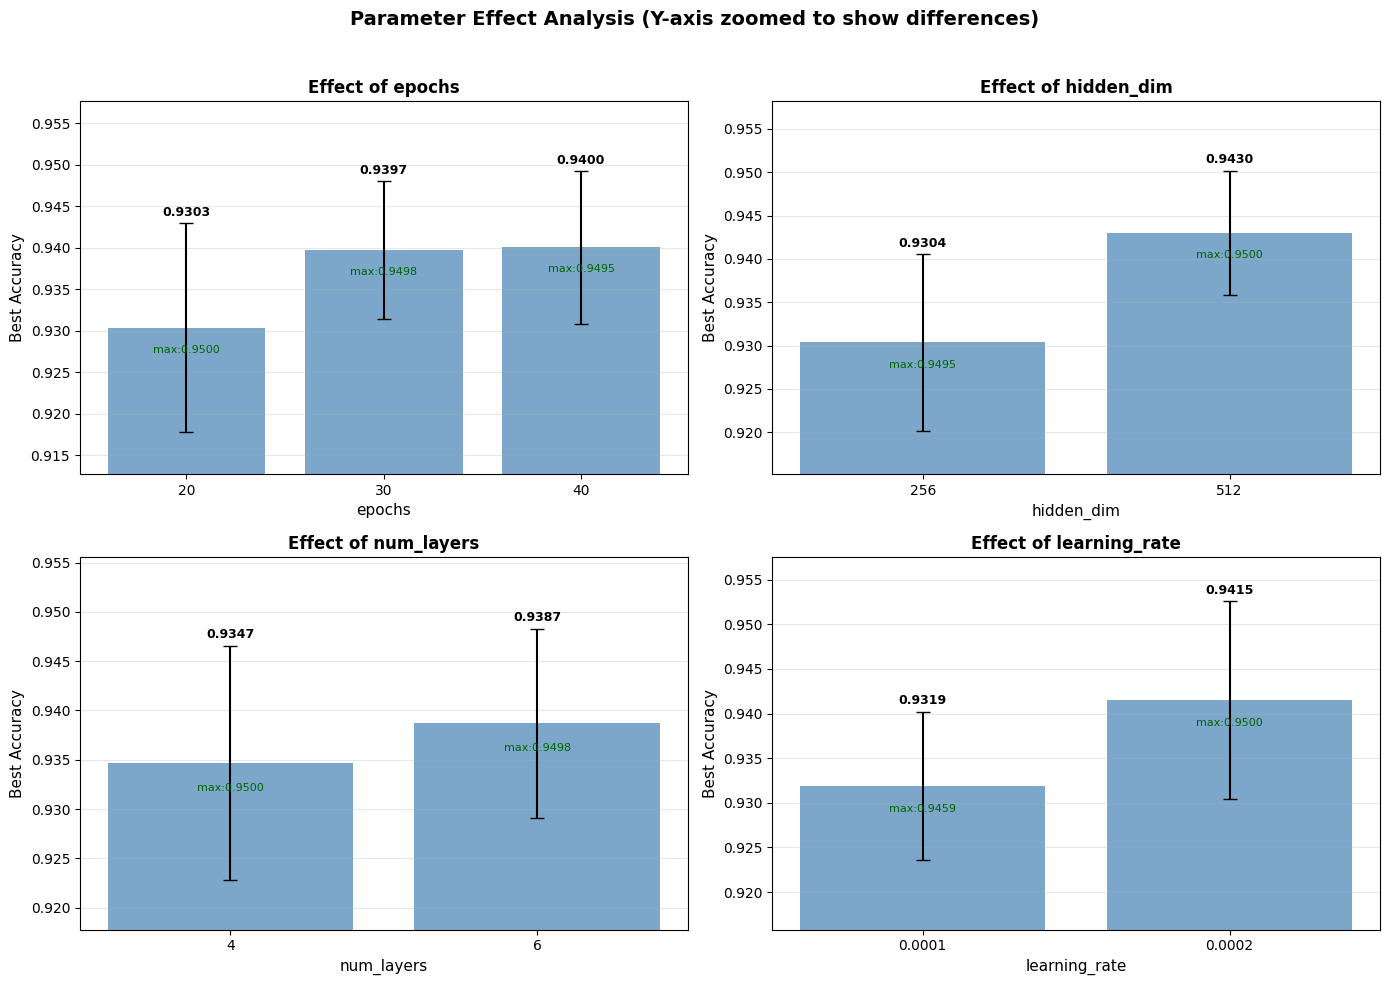

Plot saved to: /home/patrickz/EPFL_ML_PROJECT/segment_experiment_logs/param_analysis.png

Parameter Impact Summary

epochs:
  Best value: 40 (mean acc: 0.9400)
  Range: 0.9303 - 0.9400
  Diff: 0.97%

hidden_dim:
  Best value: 512 (mean acc: 0.9430)
  Range: 0.9304 - 0.9430
  Diff: 1.26%

num_layers:
  Best value: 6 (mean acc: 0.9387)
  Range: 0.9347 - 0.9387
  Diff: 0.40%

learning_rate:
  Best value: 0.0002 (mean acc: 0.9415)
  Range: 0.9319 - 0.9415
  Diff: 0.96%


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# filter successful experiments with valid accuracy
df_success = df[df["success"] & df["best_accuracy"].notna()]

if len(df_success) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, param in zip(axes, selected_search.keys()):
        grouped = df_success.groupby(param)["best_accuracy"].agg(["mean", "std", "max", "min"])
        x_pos = np.arange(len(grouped))
        
        bars = ax.bar(x_pos, grouped["mean"], yerr=grouped["std"], capsize=5, alpha=0.7, color='steelblue')
        
        # 在柱状图上添加数值标签
        for i, (bar, mean_val, max_val) in enumerate(zip(bars, grouped["mean"], grouped["max"])):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + grouped["std"].iloc[i] + 0.0005,
                    f'{mean_val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.002,
                    f'max:{max_val:.4f}', ha='center', va='top', fontsize=8, color='darkgreen')
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(x) for x in grouped.index])
        ax.set_xlabel(param, fontsize=11)
        ax.set_ylabel("Best Accuracy", fontsize=11)
        ax.set_title(f"Effect of {param}", fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        y_min = grouped["mean"].min() - grouped["std"].max() - 0.005
        y_max = grouped["mean"].max() + grouped["std"].max() + 0.005
        ax.set_ylim(max(0.9, y_min), min(1.0, y_max)) 

    plt.suptitle("Parameter Effect Analysis (Y-axis zoomed to show differences)", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(os.path.join(LOG_DIR, "param_analysis.png"), dpi=150)
    plt.show()
    print(f"Plot saved to: {LOG_DIR}/param_analysis.png")
    
    print("\n" + "="*60)
    print("Parameter Impact Summary")
    print("="*60)
    for param in selected_search.keys():
        grouped = df_success.groupby(param)["best_accuracy"].agg(["mean", "std", "max"])
        best_val = grouped["mean"].idxmax()
        print(f"\n{param}:")
        print(f"  Best value: {best_val} (mean acc: {grouped.loc[best_val, 'mean']:.4f})")
        print(f"  Range: {grouped['mean'].min():.4f} - {grouped['mean'].max():.4f}")
        print(f"  Diff: {(grouped['mean'].max() - grouped['mean'].min())*100:.2f}%")
else:
    print("No successful experiments to plot.")

In [ ]:
# find best experiment
df_valid = df[df["best_accuracy"].notna()]

if len(df_valid) > 0:
    best_idx = df_valid["best_accuracy"].idxmax()
    best_run = df_valid.loc[best_idx]

    print("="*50)
    print("Best parameter combination")
    print("="*50)
    print(f"Run: {best_run['run_name']}")
    print(f"Best Accuracy: {best_run['best_accuracy']:.4f}")
    if best_run.get('class_0_acc'):
        print(f"Class 0 Accuracy: {best_run['class_0_acc']:.4f}")
    if best_run.get('class_1_acc'):
        print(f"Class 1 Accuracy: {best_run['class_1_acc']:.4f}")
    
    print("\nBest parameters:")
    for param in selected_search.keys():
        print(f"  --{param} {best_run[param]}")
    
    # generate command line for best parameters
    print("\nBest training command:")
    cmd_parts = ["python ./model_segment.py"]
    for k, v in base_args.items():
        cmd_parts.append(f"--{k} {v}")
    for param in selected_search.keys():
        cmd_parts.append(f"--{param} {best_run[param]}")
    print(" \\\n    ".join(cmd_parts))
else:
    print("No successful experiments found.")

# save final results
df_sorted.to_csv(os.path.join(LOG_DIR, "results_summary.csv"), index=False)
print(f"\nResults saved to {LOG_DIR}/results_summary.csv")